In [ ]:
!pip install -q langgraph

# **Step 1: Define the State**

In [2]:
from typing import TypedDict, Literal

class SupportState(TypedDict):
    customer_query: str
    issue_type: str
    response: str

# **Step 2: Define Nodes**

## **NODE 1 — UNDERSTAND REQUEST**
This node receives the customer's query and displays it.

For now, it simply passes the existing state forward.

In [3]:
def understand_request(state: SupportState):
    print("Customer Query:")
    print(state["customer_query"])
    return state

## **NODE 2 — CLASSIFY REQUEST**

This node determines what type of support issue the customer has.

The classification is based on **simple keyword matching.**

In [4]:
def classify_request(state: SupportState):
    query = state["customer_query"].lower()

    if "payment" in query or "money" in query or "charged" in query:
        issue_type = "payment"

    elif "order" in query or "delivery" in query or "product" in query:
        issue_type = "order"

    else:
        issue_type = "general"

    print(f"\nIssue Classified As: {issue_type}")

    return {"issue_type": issue_type}

## **NODE 3 — CHECK PAYMENT**

This node handles payment-related customer requests.

In [6]:
def payment_node(state: SupportState):
    print("\nPayment Node")
    return {"response": "I will check your payment status."}

## **NODE 4 — CHECK ORDER STATUS**

This node handles order-related customer requests.

In [7]:
def order_node(state: SupportState):
    print("\nOrder Node")
    return {"response": "I will check your order status."}

## **NODE 5 — GENERAL SUPPORT NODE**

This node handles requests that do not match the payment or order categories.

In [8]:
def general_node(state: SupportState):
    print("\n General Support Node")
    return {"response": "I will help you with your request."}

## **NODE 6 — Response Node**

All support paths eventually reach this node.

This node represents the point where the final response is generated.

In [9]:
def generate_response(state: SupportState):
    print("\nGenerating Final Response...")
    return state

# ==================================================================

# **Step 2 EXTRAS**

## **2.2 Create the Conditional Router**

The router reads the `issue_type` from the state and decides which node should run next.

In [10]:
from typing import Literal

def route_request(state: SupportState) -> Literal["payment", "order", "general"]:
    return state["issue_type"]

# ==================================================================

# **Step 3: Initialize & BUILD the StateGraph**

Create the graph using `SupportState` as the state schema.

In [11]:
from langgraph.graph import StateGraph, START, END

In [12]:
graph = StateGraph(SupportState)

## **Step 3.1: Add Nodes to the Graph**

**Register every function as a node** in the LangGraph workflow.

In [13]:
graph.add_node("understand_request", understand_request)
graph.add_node("classify_request", classify_request)
graph.add_node("payment", payment_node)
graph.add_node("order", order_node)
graph.add_node("general", general_node)
graph.add_node("generate_response", generate_response)

## **Step 3.2: Add the Start and Classification Edges**

In [14]:
graph.add_edge(START, "understand_request")
graph.add_edge("understand_request", "classify_request")

## **Step 3.3 Check & Add the Conditional Edge**

After classification, LangGraph uses the router to choose between the payment, order, and general support paths.

In [15]:
graph.add_conditional_edges("classify_request",route_request,{"payment": "payment",
                                                              "order": "order",
                                                              "general": "general"})

### ***Connect All Support Paths***

In [16]:
graph.add_edge("payment", "generate_response")
graph.add_edge("order", "generate_response")
graph.add_edge("general", "generate_response")

### ***Connect the Final Node to END***

Once the final response is generated, the graph execution ends.

In [17]:
graph.add_edge("generate_response", END)

# ==================================================================

# **Step 4: Compile the Graph**

Compile the graph into an executable LangGraph application.

In [18]:
app = graph.compile()

## **Step 4 EXTRAS: Visualize the Graph**

Render the graph as a Mermaid diagram so we can visually inspect the workflow.

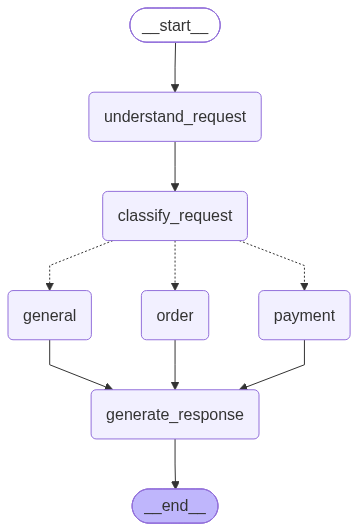

In [19]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

# ==================================================================

# **Step 5: Run the Graph**

Invoke the compiled graph with a sample customer query.

The query should be classified and routed through the appropriate support node.

In [20]:
result = app.invoke({"customer_query": "My payment was deducted but my order is pending.",
                     "issue_type": "",
                     "response": ""})

Customer Query:
My payment was deducted but my order is pending.

Issue Classified As: payment

Payment Node

Generating Final Response...


# ==================================================================

# **Step 6: Display the Final Result**

Print the complete state returned after the graph finishes execution.

In [21]:
print("\n================ FINAL RESULT ================")
print(result)


================ FINAL RESULT ================
{'customer_query': 'My payment was deducted but my order is pending.', 'issue_type': 'payment', 'response': 'I will check your payment status.'}


# ==================================================================

# **Complete Script**

The complete LangGraph implementation is provided below as one copy-pasteable script.

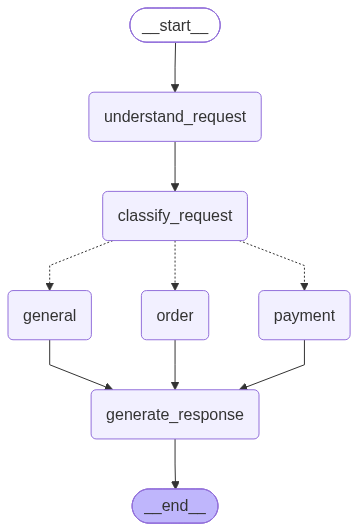

Customer Query:
My payment was deducted but my order is pending.

Issue Classified As: payment

Payment Node

Generating Final Response...

================ FINAL RESULT ================
{'customer_query': 'My payment was deducted but my order is pending.', 'issue_type': 'payment', 'response': 'I will check your payment status.'}


In [23]:
#!pip install -q langgraph

from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

class SupportState(TypedDict):
    customer_query: str
    issue_type: str
    response: str

def understand_request(state: SupportState):
    print("Customer Query:")
    print(state["customer_query"])

    return state

def classify_request(state: SupportState):
    query = state["customer_query"].lower()

    if "payment" in query or "money" in query or "charged" in query:
        issue_type = "payment"

    elif "order" in query or "delivery" in query or "product" in query:
        issue_type = "order"

    else:
        issue_type = "general"

    print(f"\nIssue Classified As: {issue_type}")

    return {
        "issue_type": issue_type
    }

def payment_node(state: SupportState):
    print("\nPayment Node")
    return {
        "response": "I will check your payment status."
    }

def order_node(state: SupportState):
    print("\n📦 Order Node")
    return {
        "response": "I will check your order status."
    }

def general_node(state: SupportState):
    print("\n💬 General Support Node")
    return {
        "response": "I will help you with your request."
    }

def generate_response(state: SupportState):
    print("\nGenerating Final Response...")

    return state

def route_request(
    state: SupportState
) -> Literal["payment", "order", "general"]:

    return state["issue_type"]

graph = StateGraph(SupportState)

graph.add_node("understand_request", understand_request)
graph.add_node("classify_request", classify_request)
graph.add_node("payment", payment_node)
graph.add_node("order", order_node)
graph.add_node("general", general_node)
graph.add_node("generate_response", generate_response)

graph.add_edge(START, "understand_request")
graph.add_edge("understand_request", "classify_request")

graph.add_conditional_edges(
    "classify_request",
    route_request,
    {
        "payment": "payment",
        "order": "order",
        "general": "general"
    }
)

graph.add_edge("payment", "generate_response")
graph.add_edge("order", "generate_response")
graph.add_edge("general", "generate_response")

graph.add_edge("generate_response", END)

app = graph.compile()

from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

result = app.invoke({
    "customer_query": "My payment was deducted but my order is pending.",
    "issue_type": "",
    "response": ""
})

print("\n================ FINAL RESULT ================")
print(result)